# Ride Fare Dynamic Pricing

Business Objective: A leading ride-sharing company currently prices rides mainly based on expected duration. They want a dynamic pricing model that incorporates real-time supply-demand imbalance, customer profile, time, location, and vehicle type to:

Increase revenue through dynamic pricing
Improve fleet allocation during peak hours
Maintain customer retention (avoid over-pricing)

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler


df = pd.read_csv("data.csv")
display(df.head(5))

,Riders,Drivers,Category,Loyalty,Time,Vehicle_Type,Past_Rides,Ratings,Duration,Cost
0,90,45,Urban,Silver,Night,Premium,13,4.47,90,284.257273
1,58,39,Suburban,Silver,Evening,Economy,72,4.06,43,173.874753
2,42,31,Rural,Silver,Afternoon,Premium,0,3.99,76,329.795469
3,89,28,Rural,Regular,Afternoon,Premium,67,4.31,134,470.201232
4,78,22,Rural,Regular,Afternoon,Economy,74,3.77,149,579.681422


In [2]:
# Feature Engineering 


df['Supply_Gap'] = df['Riders'] - df['Drivers']
df["Demand"] = df["Riders"] / df["Drivers"]
df["Demand_Status"] = pd.qcut(
    df["Demand"], q=4,
    labels=["Low Demand", "Moderate", "High Demand", "Extreme Surge"],
)
df["Unit_Price"] = df["Cost"] / df["Duration"]

time_map = {"Morning": 1, "Night": 1, "Afternoon": 2, "Evening": 2}
vehicle_map = {"Premium": 1, "Economy": 2}
loyalty_map = {"Gold": 1, "Silver": 2, "Regular": 3}

df["Time_Priority"] = df["Time"].map(time_map)
df["Vehicle_Priority"] = df["Vehicle_Type"].map(vehicle_map)
df["Loyalty_Priority"] = df["Loyalty"].map(loyalty_map)

ordinal_encoder = OrdinalEncoder(categories=[
    ["Gold", "Silver", "Regular"],  
    ["Premium", "Economy"],  
])

df[["Loyalty_Priority", "Vehicle_Priority"]] = (
    ordinal_encoder.fit_transform(df[["Loyalty", "Vehicle_Type"]]) + 1
)

display(df.head(5))

,Riders,Drivers,Category,Loyalty,Time,Vehicle_Type,Past_Rides,Ratings,Duration,Cost,Supply_Gap,Demand,Demand_Status,Unit_Price,Time_Priority,Vehicle_Priority,Loyalty_Priority
0,90,45,Urban,Silver,Night,Premium,13,4.47,90,284.257273,45,2.000000,Moderate,3.158414,1,1.0,2.0
1,58,39,Suburban,Silver,Evening,Economy,72,4.06,43,173.874753,19,1.487179,Low Demand,4.043599,2,2.0,2.0
2,42,31,Rural,Silver,Afternoon,Premium,0,3.99,76,329.795469,11,1.354839,Low Demand,4.339414,2,1.0,2.0
3,89,28,Rural,Regular,Afternoon,Premium,67,4.31,134,470.201232,61,3.178571,High Demand,3.508964,2,1.0,3.0
4,78,22,Rural,Regular,Afternoon,Economy,74,3.77,149,579.681422,56,3.545455,High Demand,3.890479,2,2.0,3.0


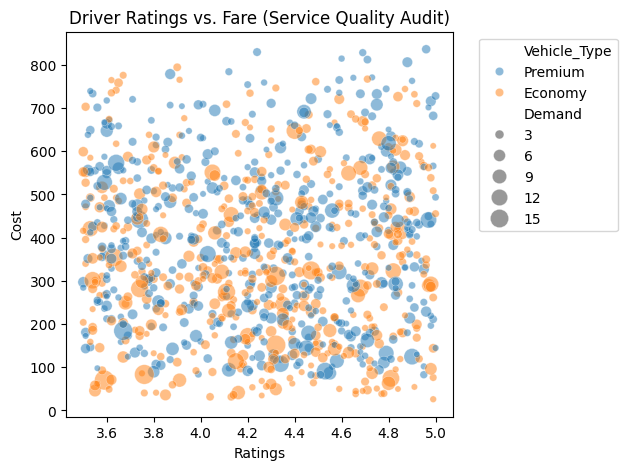

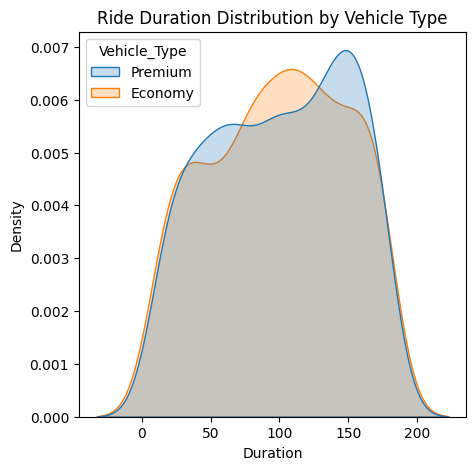

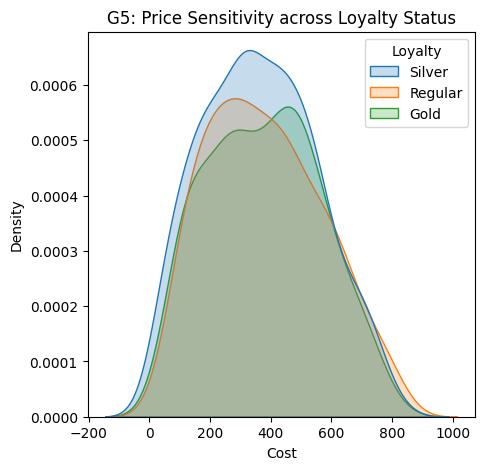

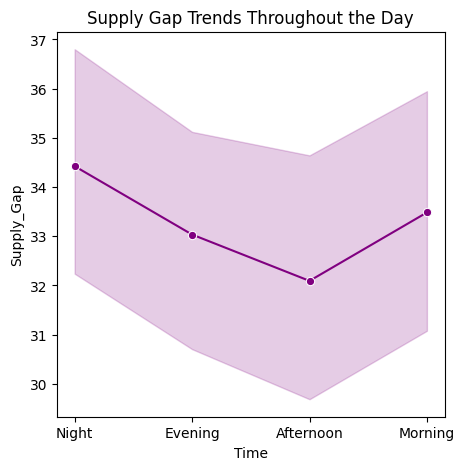

In [3]:
# Identify feature types
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns

plt.figure(figsize=(5, 5))
sns.scatterplot(data=df, x='Ratings', y='Cost', hue='Vehicle_Type', size='Demand', alpha=0.5, sizes=(20, 200))
plt.title("Driver Ratings vs. Fare (Service Quality Audit)")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

plt.figure(figsize=(5, 5))
sns.kdeplot(data=df, x='Duration', hue='Vehicle_Type', fill=True, common_norm=False)
plt.title("Ride Duration Distribution by Vehicle Type")
plt.show()

plt.figure(figsize=(5, 5))
sns.kdeplot(data=df, x='Cost', hue='Loyalty', fill=True)
plt.title("G5: Price Sensitivity across Loyalty Status")
plt.show()

plt.figure(figsize=(5, 5))
sns.lineplot(data=df, x='Time', y='Supply_Gap', marker='o', color='purple')
plt.title("Supply Gap Trends Throughout the Day")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_2640\2618574598.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Loyalty', y='Unit_Price', palette="Set2", inner="quart")


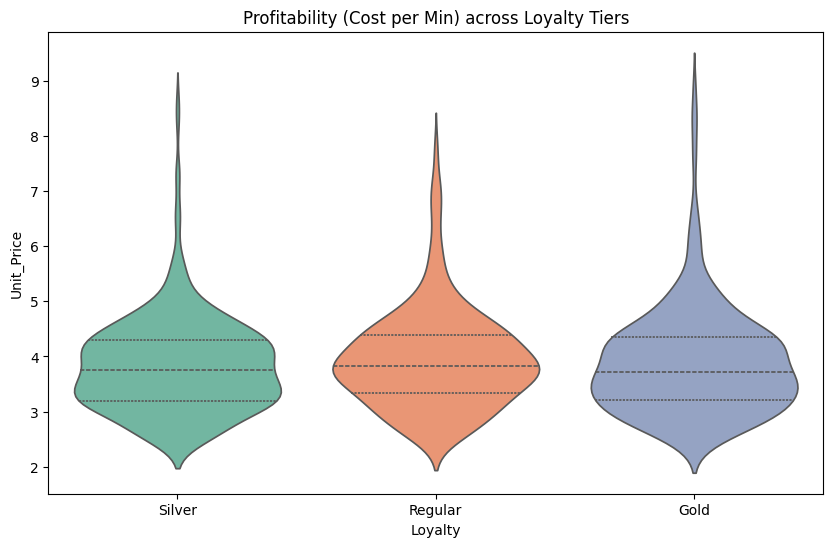

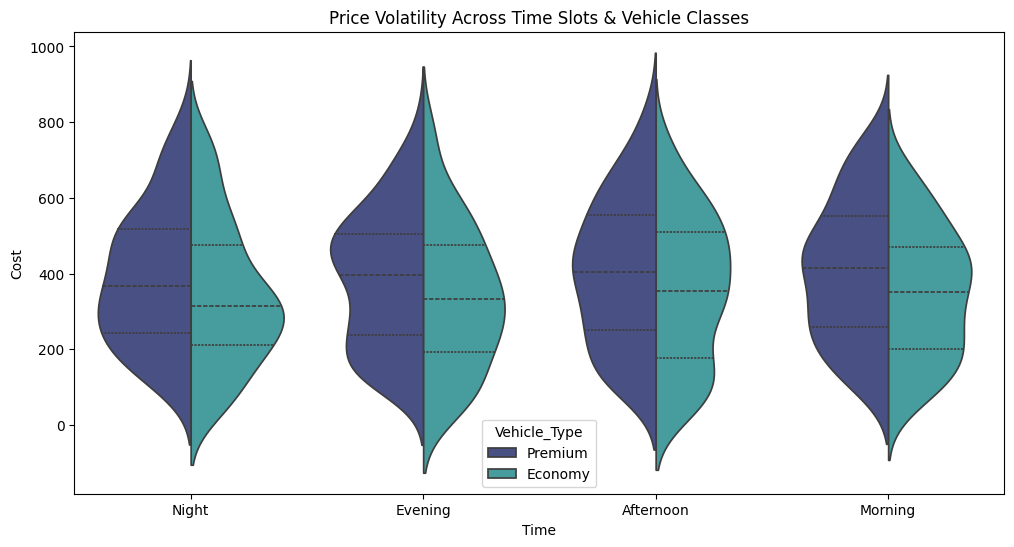

In [4]:
# Loyalty vs Profitability
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Loyalty', y='Unit_Price', palette="Set2", inner="quart")
plt.title("Profitability (Cost per Min) across Loyalty Tiers")
plt.show()

plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Time', y='Cost', hue='Vehicle_Type', split=True, palette="mako", inner="quartile")
plt.title("Price Volatility Across Time Slots & Vehicle Classes")
plt.show()

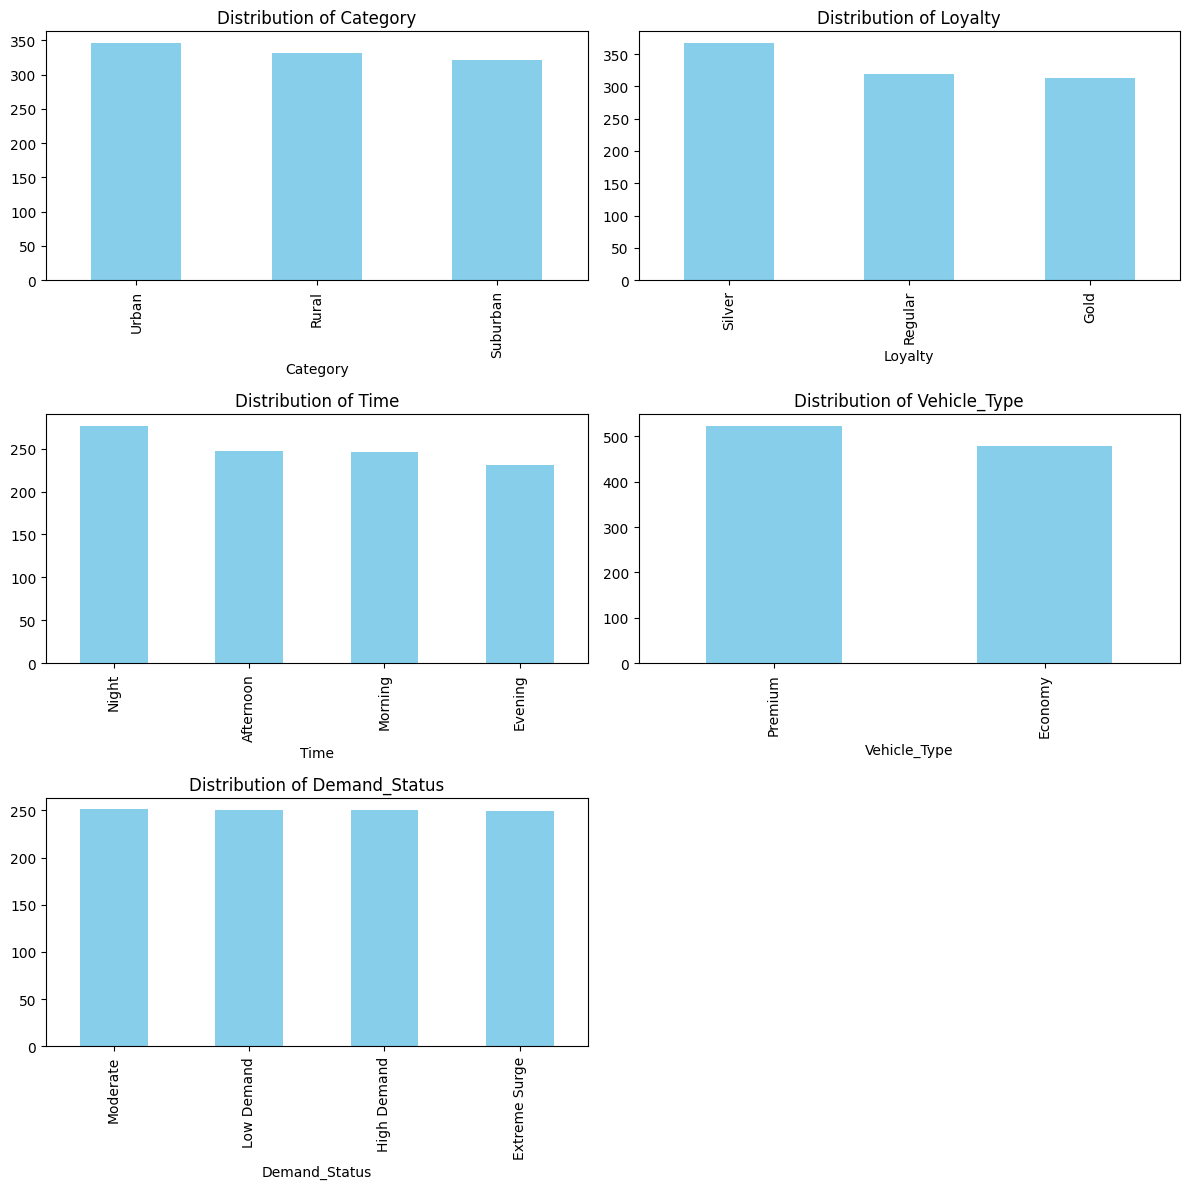

In [5]:
# 2. Categorical Feature Distributions
n_cat = len(cat_cols)
rows_cat = (n_cat + 1) // 2
fig, axes = plt.subplots(rows_cat, 2, figsize=(12, rows_cat * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind="bar", ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribution of {col}")

for j in range(n_cat, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

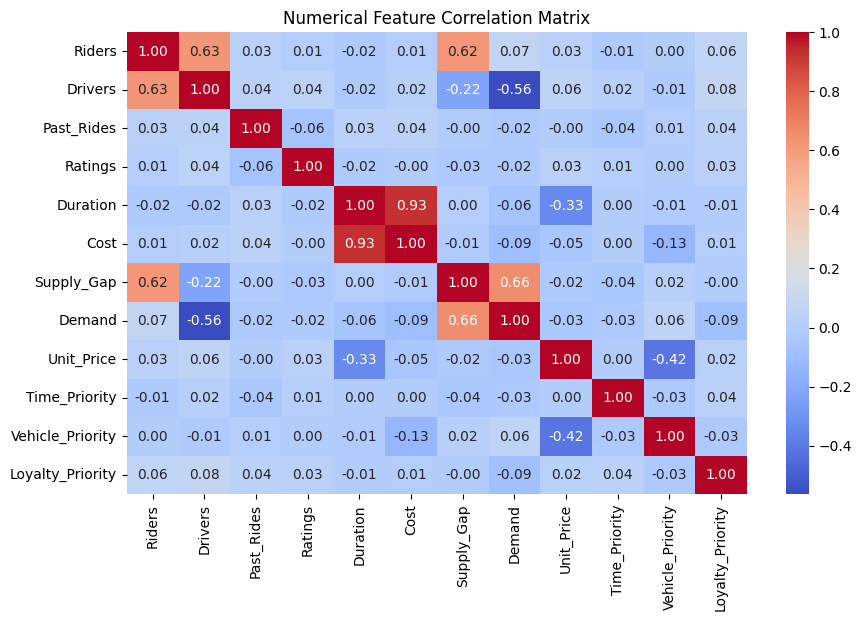

In [6]:
# 3. Correlation Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Numerical Feature Correlation Matrix")
plt.show()

In [7]:
# Train Test Split
X = df.drop(columns=["Cost"])
y = df["Cost"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.20, random_state = 42, 
    shuffle=True, stratify = df['Demand_Status']
)

print(f"Train set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Train set size: (800, 16)
Test set size: (200, 16)


In [8]:
# Pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, make_column_selector(dtype_include=np.number)),
    ("cat", cat_pipeline, make_column_selector(dtype_exclude=np.number))
])

In [9]:
# Model Training
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LinearRegression())
])
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestRegressor(n_estimators=300, random_state=42))  
])
gbr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingRegressor(n_estimators=300, random_state=42)) 
])

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
gbr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [10]:
# Final Model Selection

models = {
    "Linear Regression": lr_pipeline,
    "Random Forest Regressor": rf_pipeline,
    "Gradient Boosting Regressor": gbr_pipeline,
}


def evaluate_regression(model, name, X_val, y_val):
    y_pred = model.predict(X_val)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}


# Evaluate all models on test set
results = []
for name, model in models.items():
    results.append(evaluate_regression(model, name, X_test, y_test))

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"\nBest Performing Model: {best_model_name}")

,Model,MAE,RMSE,R2
2,Gradient Boosting Regressor,6.760507,8.417196,0.997684
1,Random Forest Regressor,7.509584,9.979722,0.996744
0,Linear Regression,32.039232,44.023576,0.936633



Best Performing Model: Gradient Boosting Regressor


In [12]:
# Model Serialization
joblib.dump(best_model, "model.pkl")
print("Model saved successfully.")

Model saved successfully.
